Instructor Effectiveness Prediction Using Machine Learning
Random Forest Classification Model

Course Project – Data Analytics / Machine Learning

Introduction

This project analyzes instructor effectiveness using student performance
and engagement data. The dataset contains 2000 records with metrics such as
completion rate, quiz scores, watch time, assignment submission rate,
forum activity, and feedback scores.

The goal of this project is to build a machine learning model that can
predict instructor effectiveness levels based on these metrics.

A Random Forest classification model is used to categorize instructors
into three effectiveness tiers:
Low, Medium, and High.

The workflow includes:
• Data exploration
• Feature engineering
• Correlation analysis
• Model training and testing
• Model evaluation
• Interpretation of results

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [6]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'instructor_effectiveness_dataset_2000_rows.csv'

In [7]:
import os
os.listdir()

['Music',
 '.DS_Store',
 '.CFUserTextEncoding',
 'Pictures',
 '.zprofile',
 '.zsh_history',
 '.ipython',
 'Desktop',
 'Library',
 '.matplotlib',
 'Public',
 'Movies',
 'instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv',
 'Applications',
 '.Trash',
 'IdeaProjects',
 '.ipynb_checkpoints',
 'Documents',
 '.mysql_history',
 '.vscode',
 'Downloads',
 '.zsh_sessions',
 'Instructor_Effectiveness_Model.ipynb']

In [8]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [9]:
df.shape

(2000, 12)

In [10]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [12]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [13]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

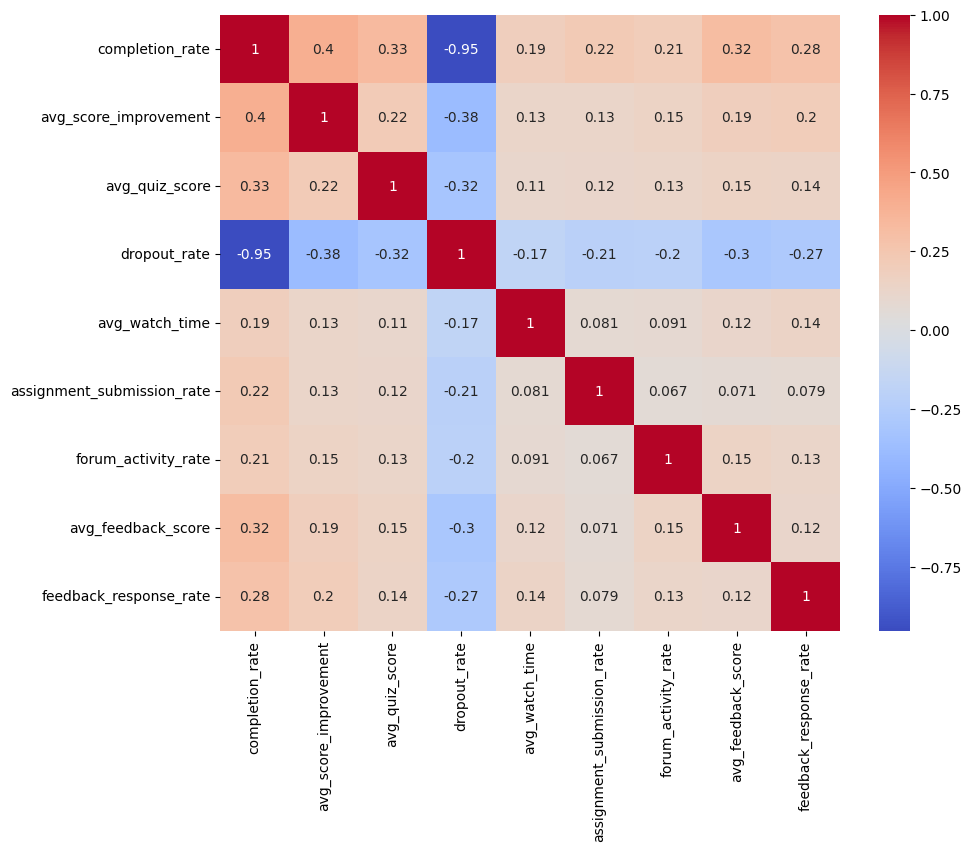

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [15]:
df["effectiveness_score"] = (
    0.25 * df["completion_rate"] +
    0.15 * df["avg_score_improvement"] / 40 +
    0.15 * df["avg_quiz_score"] / 100 +
    0.20 * (1 - df["dropout_rate"]) +
    0.10 * df["avg_watch_time"] +
    0.05 * df["assignment_submission_rate"] +
    0.05 * df["forum_activity_rate"] +
    0.03 * df["avg_feedback_score"] / 5 +
    0.02 * df["feedback_response_rate"]
)

In [16]:
df[["instructor_id","effectiveness_score"]].head()

,instructor_id,effectiveness_score
0,I_044,0.464867
1,I_119,0.639152
2,I_050,0.497912
3,I_024,0.705310
4,I_001,0.681397


In [17]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

In [18]:
df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

In [19]:
instructor_df = df.groupby("instructor_id").mean(numeric_only=True).reset_index()

In [20]:
tier_map = df.groupby("instructor_id")["effectiveness_tier"].first().reset_index()

instructor_df = instructor_df.merge(tier_map, on="instructor_id")

In [21]:
instructor_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,effectiveness_tier
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,0.624336,Medium
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,0.747693,Medium
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,0.758528,High
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,0.575000,Low
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,0.822864,High


In [22]:
X = instructor_df.drop(["instructor_id","effectiveness_tier","effectiveness_score"], axis=1)

y = instructor_df["effectiveness_tier"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

Hyperparameter Optimization : 
To improve model performance, we perform hyperparameter tuning using
GridSearchCV. This helps identify the optimal parameters for the
Random Forest classifier by testing multiple parameter combinations.

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [30]:
pred = best_model.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.7916666666666666
              precision    recall  f1-score   support

        High       1.00      0.83      0.91         6
         Low       0.80      0.57      0.67         7
      Medium       0.71      0.91      0.80        11

    accuracy                           0.79        24
   macro avg       0.84      0.77      0.79        24
weighted avg       0.81      0.79      0.79        24



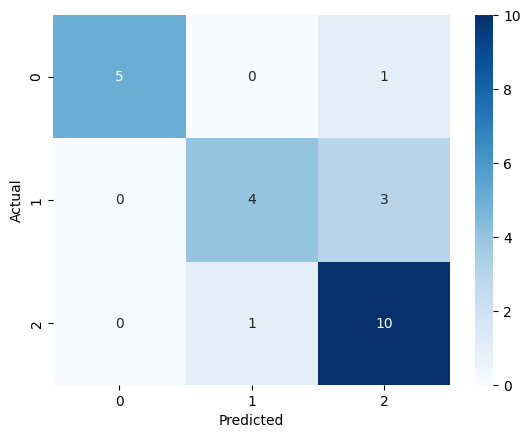

In [28]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Interpretation / Insights

1. Key Features Influencing Instructor Effectiveness

From the correlation analysis and model performance, the most influential factors affecting instructor effectiveness include:
	•	Completion Rate – Indicates how many students successfully finish the course.
	•	Dropout Rate – A strong negative indicator of instructional effectiveness.
	•	Average Quiz Score – Reflects how well students understand the course material.
	•	Average Score Improvement – Shows how much students improved during the course.
Hyperparameter tuning using GridSearchCV was applied to optimize the Random Forest model and improve predictive performance.

Student engagement metrics such as watch time, assignment submission rate, and forum activity also contribute to instructor effectiveness but generally have a smaller influence compared to learning outcome metrics.

2. Potentially Misleading Features

Some variables may not purely reflect instructor quality and could introduce bias:
	•	Forum Activity Rate may depend on the difficulty of the course rather than teaching effectiveness.
	•	Average Watch Time may be influenced by course length or student motivation rather than teaching quality.
	•	Assignment Submission Rate may vary depending on course workload or assessment structure.

Therefore, these metrics should be interpreted carefully when evaluating instructor performance.

3. Risks or Failure Cases of the Model

The model may produce inaccurate predictions in certain situations:
	•	Courses with very different difficulty levels may bias effectiveness scores.
	•	Instructors who teach only a small number of batches may have unreliable effectiveness estimates.
	•	External factors such as student background, prior knowledge, or motivation are not captured in the dataset.

Because of these limitations, the model should be interpreted as an analytical tool rather than a definitive measure of teaching quality.

4. Additional Data That Would Improve the Model

The model could be improved by including additional variables such as:
	•	Student demographic information
	•	Course difficulty level
	•	Instructor teaching experience
	•	Student satisfaction surveys
	•	Direct instructor–student interaction metrics

Incorporating these variables would provide a more comprehensive evaluation of instructor effectiveness.

5. Should This Model Be Used for Instructor Evaluation?

This model can provide useful insights into instructor performance, but it should not be used as the only evaluation metric.

Instead, it should complement other evaluation methods such as:
	•	qualitative teaching assessments
	•	peer reviews
	•	student feedback

Combining quantitative analytics with qualitative evaluation ensures a more balanced and fair assessment of instructor performance.

Final Conclusion

This analysis demonstrates how machine learning can be applied to educational data to evaluate instructor effectiveness. By combining student engagement metrics, learning outcomes, and feedback indicators, a predictive model was developed to classify instructors into effectiveness tiers. The Random Forest model achieved an accuracy of approximately 79%, showing that data-driven approaches can help identify effective teaching patterns and highlight areas for improvement.